In [65]:
# basics libraries
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pandas.plotting import register_matplotlib_converters

# Libraries for maps
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Units libraries
import metpy.calc as mpcalc
from metpy.units import units

# Time libraries
import matplotlib.dates as mdates

# For metocean statistics
from metocean_stats import plots, tables

# Plots libraries
import matplotlib.colors as mcolors
import seaborn as sns
import matplotlib.colors as colors
from matplotlib.lines import Line2D

Dataset used for latitude, longitude definition

In [66]:
ds_0 = xr.open_dataset("C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Maps_diff//hs_mean_diff01.nc", engine="h5netcdf")
ds_0

<xarray.Dataset> Size: 16MB
Dimensions:    (time: 1, bnds: 2, latitude: 787, longitude: 1651)
Coordinates:
    latitude   (latitude, longitude) float32 5MB ...
    longitude  (latitude, longitude) float32 5MB ...
  * time       (time) datetime64[ns] 8B 2020-01-16T11:30:00
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 16B ...
    diff       (time, latitude, longitude) float32 5MB ...
Attributes: (12/22)
    CDI:                              Climate Data Interface version 1.9.6 (h...
    Conventions:                      CF-1.6
    WAVEWATCH_III_version_number:     6.07
    WAVEWATCH_III_switches:           F90 NOGRB NC4 SHRD PR3 UQ FLX0 LN1 ST4 ...
    SIN4 namelist parameter BETAMAX:  1.55
    product_name:                     ww3.run_with_currents202001.nc
    ...                               ...
    start_date:                       2020-01-01 00:00:00
    stop_date:                        2020-01-31 23:00:00
    CDO:                              Climate Data Operators version 1.9.6 (h...
    history:                          Thu Oct  9 13:26:05 2025: ncks -A lan_l...
    history_of_appended_files:        Thu Oct  9 13:26:05 2025: Appended file...
    NCO:                              "4.5.2"

Define datasets

In [67]:
# No currents 
#ds_1 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Analysis//Ianos//Data//formation//Ianos_no_cur_formation.nc", engine="h5netcdf")
#ds_1 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Analysis//Ianos//Data//dissipitation//Ianos_no_cur_dissipitation.nc", engine="h5netcdf")
ds_1 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Analysis//Ianos//Data//intense_period//Ianos_no_cur_intense.nc", engine="h5netcdf")
ds_1

<xarray.Dataset> Size: 559MB
Dimensions:    (latitude: 787, longitude: 1651, time: 15)
Coordinates:
    latitude   (latitude, longitude) float32 5MB ...
    longitude  (latitude, longitude) float32 5MB ...
  * time       (time) datetime64[ns] 120B 2020-09-16T22:00:00 ... 2020-09-17T...
Data variables:
    MAPSTA     (latitude, longitude) int16 3MB ...
    dir        (time, latitude, longitude) float32 78MB ...
    fp         (time, latitude, longitude) float32 78MB ...
    hs         (time, latitude, longitude) float32 78MB ...
    spr        (time, latitude, longitude) float32 78MB ...
    t01        (time, latitude, longitude) float32 78MB ...
    t02        (time, latitude, longitude) float32 78MB ...
    t0m1       (time, latitude, longitude) float32 78MB ...
Attributes: (12/22)
    CDI:                              Climate Data Interface version 1.9.6 (h...
    history:                          Wed Dec 10 14:51:13 2025: cdo --sortnam...
    Conventions:                      CF-1.6
    WAVEWATCH_III_version_number:     6.07
    WAVEWATCH_III_switches:           F90 NOGRB NC4 SHRD PR3 UQ FLX0 LN1 ST4 ...
    SIN4 namelist parameter BETAMAX:  1.55
    ...                               ...
    altitude_resolution:              n/a
    start_date:                       2020-09-01 00:00:00
    stop_date:                        2020-09-30 23:00:00
    history_of_appended_files:        Tue Nov  4 13:25:33 2025: Appended file...
    NCO:                              "4.5.2"
    CDO:                              Climate Data Operators version 1.9.6 (h...

In [68]:
# Differnce between two runs
#ds_2 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Analysis//Ianos//Data//formation//Ianos_diff_formation.nc", engine="h5netcdf")
#ds_2 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Analysis//Ianos//Data//dissipitation//Ianos_diff_dissipitation.nc", engine="h5netcdf")
ds_2 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Analysis//Ianos//Data//intense_period//Ianos_diff_intense.nc", engine="h5netcdf")
ds_2

<xarray.Dataset> Size: 559MB
Dimensions:    (latitude: 787, longitude: 1651, time: 15)
Coordinates:
    latitude   (latitude, longitude) float32 5MB ...
    longitude  (latitude, longitude) float32 5MB ...
  * time       (time) datetime64[ns] 120B 2020-09-16T22:00:00 ... 2020-09-17T...
Data variables:
    MAPSTA     (latitude, longitude) int16 3MB ...
    dir        (time, latitude, longitude) float32 78MB ...
    fp         (time, latitude, longitude) float32 78MB ...
    hs         (time, latitude, longitude) float32 78MB ...
    spr        (time, latitude, longitude) float32 78MB ...
    t01        (time, latitude, longitude) float32 78MB ...
    t02        (time, latitude, longitude) float32 78MB ...
    t0m1       (time, latitude, longitude) float32 78MB ...
Attributes: (12/21)
    CDI:                              Climate Data Interface version 1.9.6 (h...
    history:                          Wed Dec 10 14:51:46 2025: cdo sub Ianos...
    Conventions:                      CF-1.6
    WAVEWATCH_III_version_number:     6.07
    WAVEWATCH_III_switches:           F90 NOGRB NC4 SHRD PR3 UQ FLX0 LN1 ST4 ...
    SIN4 namelist parameter BETAMAX:  1.55
    ...                               ...
    maximum_altitude:                 9000 m
    altitude_resolution:              n/a
    start_date:                       2020-09-01 00:00:00
    stop_date:                        2020-09-30 23:00:00
    NCO:                              "4.5.2"
    CDO:                              Climate Data Operators version 1.9.6 (h...

In [69]:
# Forcings
#ds_3 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Analysis//Ianos//Data//formation//forcings.nc", engine="h5netcdf")
#ds_3 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Analysis//Ianos//Data//dissipitation//forcings_dissipitation.nc", engine="h5netcdf")
ds_3 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Analysis//Ianos//Data//intense_period//forcings_intense.nc", engine="h5netcdf")
ds_3

<xarray.Dataset> Size: 322MB
Dimensions:    (latitude: 787, longitude: 1651, time: 15)
Coordinates:
    latitude   (latitude, longitude) float32 5MB ...
    longitude  (latitude, longitude) float32 5MB ...
  * time       (time) datetime64[ns] 120B 2020-09-16T22:00:00 ... 2020-09-17T...
Data variables:
    ucur       (time, latitude, longitude) float32 78MB ...
    uwnd       (time, latitude, longitude) float32 78MB ...
    vcur       (time, latitude, longitude) float32 78MB ...
    vwnd       (time, latitude, longitude) float32 78MB ...
Attributes:
    history:                    Wed Dec 10 14:48:48 2025: ncks -A -v ucur,vcu...
    history_of_appended_files:  Wed Dec 10 14:48:48 2025: Appended file Ianos...
    NCO:                        "4.5.2"

In [70]:
# With currents
#ds_4 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Analysis//Ianos//Data//formation//Ianos_with_cur_formation.nc", engine="h5netcdf")
#ds_4 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Analysis//Ianos//Data//dissipitation//Ianos_with_cur_dissipitation.nc", engine="h5netcdf")
ds_4 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Analysis//Ianos//Data//intense_period//Ianos_with_cur_intense.nc", engine="h5netcdf")
ds_4

<xarray.Dataset> Size: 559MB
Dimensions:    (latitude: 787, longitude: 1651, time: 15)
Coordinates:
    latitude   (latitude, longitude) float32 5MB ...
    longitude  (latitude, longitude) float32 5MB ...
  * time       (time) datetime64[ns] 120B 2020-09-16T22:00:00 ... 2020-09-17T...
Data variables:
    MAPSTA     (latitude, longitude) int16 3MB ...
    dir        (time, latitude, longitude) float32 78MB ...
    fp         (time, latitude, longitude) float32 78MB ...
    hs         (time, latitude, longitude) float32 78MB ...
    spr        (time, latitude, longitude) float32 78MB ...
    t01        (time, latitude, longitude) float32 78MB ...
    t02        (time, latitude, longitude) float32 78MB ...
    t0m1       (time, latitude, longitude) float32 78MB ...
Attributes: (12/21)
    CDI:                              Climate Data Interface version 1.9.6 (h...
    history:                          Wed Dec 10 14:50:52 2025: cdo --sortnam...
    Conventions:                      CF-1.6
    WAVEWATCH_III_version_number:     6.07
    WAVEWATCH_III_switches:           F90 NOGRB NC4 SHRD PR3 UQ FLX0 LN1 ST4 ...
    SIN4 namelist parameter BETAMAX:  1.55
    ...                               ...
    maximum_altitude:                 9000 m
    altitude_resolution:              n/a
    start_date:                       2020-09-01 00:00:00
    stop_date:                        2020-09-30 23:00:00
    NCO:                              "4.5.2"
    CDO:                              Climate Data Operators version 1.9.6 (h...

Assing coordinates to the data

In [71]:
ds_1 = ds_1.assign_coords(latitude=ds_0.latitude,longitude=ds_0.longitude)
ds_2 = ds_2.assign_coords(latitude=ds_0.latitude, longitude=ds_0.longitude)
ds_3 = ds_3.assign_coords(latitude=ds_0.latitude,longitude=ds_0.longitude)
ds_4 = ds_4.assign_coords(latitude=ds_0.latitude, longitude=ds_0.longitude)
ds_2

<xarray.Dataset> Size: 559MB
Dimensions:    (latitude: 787, longitude: 1651, time: 15)
Coordinates:
    latitude   (latitude, longitude) float32 5MB ...
    longitude  (latitude, longitude) float32 5MB ...
  * time       (time) datetime64[ns] 120B 2020-09-16T22:00:00 ... 2020-09-17T...
Data variables:
    MAPSTA     (latitude, longitude) int16 3MB ...
    dir        (time, latitude, longitude) float32 78MB ...
    fp         (time, latitude, longitude) float32 78MB ...
    hs         (time, latitude, longitude) float32 78MB ...
    spr        (time, latitude, longitude) float32 78MB ...
    t01        (time, latitude, longitude) float32 78MB ...
    t02        (time, latitude, longitude) float32 78MB ...
    t0m1       (time, latitude, longitude) float32 78MB ...
Attributes: (12/21)
    CDI:                              Climate Data Interface version 1.9.6 (h...
    history:                          Wed Dec 10 14:51:46 2025: cdo sub Ianos...
    Conventions:                      CF-1.6
    WAVEWATCH_III_version_number:     6.07
    WAVEWATCH_III_switches:           F90 NOGRB NC4 SHRD PR3 UQ FLX0 LN1 ST4 ...
    SIN4 namelist parameter BETAMAX:  1.55
    ...                               ...
    maximum_altitude:                 9000 m
    altitude_resolution:              n/a
    start_date:                       2020-09-01 00:00:00
    stop_date:                        2020-09-30 23:00:00
    NCO:                              "4.5.2"
    CDO:                              Climate Data Operators version 1.9.6 (h...

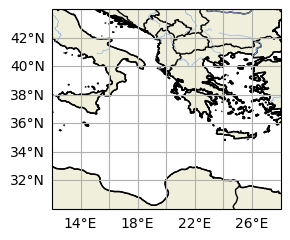

In [72]:
fig = plt.figure(figsize=(10,10)) 
ax = fig.add_axes([0.5, 1, 0.3, 0.2], projection=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cfeature.BORDERS, zorder=1, edgecolor='k')
ax.add_feature(cfeature.RIVERS, linewidth=0.5)
    
gl = ax.gridlines(draw_labels=True)
gl.right_labels = False
gl.top_labels = False

# Customize mini map
ax.add_feature(cfeature.LAND, zorder=0, edgecolor='k')                  # add land mask
ax.set_extent([12, 28, 30, 44], crs = ccrs.PlateCarree())               # define the extent of the mini map [lon_min,lon_max,lat_min,lat_max]


In [73]:
Range_of_regions = {"range" : [12, 28, 30, 44]}
List_dataset_index = ["0","1","2","3","4"]
ds_model_list = [ds_0, ds_1, ds_2, ds_3, ds_4]

for i in range(len(List_dataset_index)):
    globals()[f"ds_{List_dataset_index[i]}_sel"] = ds_model_list[i].where(
    (ds_0.longitude >= Range_of_regions["range"][0]) & 
    (ds_0.longitude <= Range_of_regions["range"][1]) &
    (ds_0.latitude >= Range_of_regions["range"][2]) & 
    (ds_0.latitude <= Range_of_regions["range"][3]),
    drop=True
)
    
ds_0 = ds_0_sel
ds_1 = ds_1_sel
ds_2 = ds_2_sel
ds_3 = ds_3_sel
ds_4 = ds_4_sel

In [74]:
# Setting variables from dataset

# Standard wave parameters : Hs, t01, t02, t0m1, fp, dir, spr, c_group, stepness, wavelength

# lat-lon
lon = ds_0["longitude"]
lat = ds_0["latitude"]

# diff
diff_hs = ds_2["hs"][:,:,:]
diff_t01 = ds_2["t01"][:,:,:]
diff_spread = ds_2["spr"][:,:,:]
diff_wave_dir = ds_2["dir"][:,:,:]
diff_fp = ds_2["fp"][:,:,:]

# forcings
ucur = ds_3["ucur"][:,:,:]
vcur = ds_3["vcur"][:,:,:]
uwnd = ds_3["uwnd"][:,:,:]
vwnd = ds_3["vwnd"][:,:,:]

# no currents parameters
hs_no_cur = ds_1["hs"][:,:,:]
t01_no_cur = ds_1["t01"][:,:,:]
spread_no_cur = ds_1["spr"][:,:,:]
wave_dir_no_cur = ds_1["dir"][:,:,:]
fp_no_cur = ds_1["fp"][:,:,:]

# with currents parameters
wave_dir_with_cur = ds_4["dir"][:,:,:]
t01_with_cur = ds_4["t01"][:,:,:]
hs_with_cur = ds_4["hs"][:,:,:]

Setting values of variables

In [75]:
# lat-lon
lon2d = lon.values
lat2d = lat.values

# diff
diff_hs2d = diff_hs.values * units("m")
diff_t012d = diff_t01.values * units("s")
diff_spread = diff_spread.values
diff_wave_dir2d = diff_wave_dir.values
diff_fp2d = diff_fp.values * units("1/s")

# forcings
ucur2d = ucur.values * units("m/s") 
vcur2d = vcur.values * units("m/s")
uwnd2d = uwnd.values * units("m/s")
vwnd2d = vwnd.values * units("m/s")

# no currents parameters
hs_no_cur = hs_no_cur.values * units("m")
t01_no_cur = t01_no_cur.values * units("s")
spread_no_cur = spread_no_cur.values
wave_dir_no_cur = wave_dir_no_cur.values
fp_no_cur = fp_no_cur.values * units("1/s")

# with currents parameters
wave_dir_with_cur = wave_dir_with_cur.values
t01_with_cur = t01_with_cur.values * units("s")
hs_with_cur = hs_with_cur.values * units("m")

In [76]:
wnd_speed = np.sqrt(uwnd2d**2 + vwnd2d**2)
cur_speed = np.sqrt(ucur2d**2 + vcur2d**2) 
g = 9.81 * units("m/s**2")
c_phase_with_cur=(g*t01_with_cur)/(2*np.pi)
c_group_with_cur=(g*t01_with_cur)/(4*np.pi) 
c_phase_no_cur=(g*t01_no_cur)/(2*np.pi) 
c_group_no_cur=(g*t01_no_cur)/(4*np.pi) 
wavelength_with_cur=(g*(t01_with_cur**2))/(2*np.pi) 
stepness_with_cur = (hs_with_cur)/(wavelength_with_cur)
wave_age_with_cur = (c_phase_with_cur)/(wnd_speed)

c:\Users\kosta\AppData\Local\Programs\Python\Python313\Lib\site-packages\pint\facets\plain\quantity.py:1029: RuntimeWarning: divide by zero encountered in divide
  magnitude = magnitude_op(new_self._magnitude, other._magnitude)


In [77]:
wnd_dir = np.degrees(np.arctan2(vwnd, uwnd))
wnd_dir = (270 - wnd_dir) % 360
cur_dir = np.degrees(np.arctan2(vcur, ucur))
cur_dir = (270 - cur_dir) % 360

In [78]:
angle_bet_cur_wave =  cur_dir - wave_dir_no_cur
angle_bet_cur_wave_with =  cur_dir - wave_dir_with_cur
angle_bet_cur_wnd = cur_dir - wnd_dir
angle_bet_wave_wnd = wave_dir_with_cur - wnd_dir

Computation of relative angles

Angle bet cur and wnd

In [79]:
rel_angle_cur_wnd = xr.where((wnd_dir < 180) & (angle_bet_cur_wnd <= 180), angle_bet_cur_wnd, xr.where(
    (wnd_dir < 180) & (angle_bet_cur_wnd > 180), angle_bet_cur_wnd - 360, xr.where(
        (wnd_dir > 180) & (angle_bet_cur_wnd >= -180), angle_bet_cur_wnd, xr.where(
            (wnd_dir > 180) & (angle_bet_cur_wnd < -180), 360 + angle_bet_cur_wnd, angle_bet_cur_wnd)
    ) 
))
np.nanmax(rel_angle_cur_wnd), np.nanmin(rel_angle_cur_wnd),np.shape(rel_angle_cur_wnd)

(np.float32(179.99985), np.float32(-179.99976), (15, 737, 598))

Angle between cur and wave

In [80]:
rel_angle_wave = xr.where((wave_dir_no_cur < 180) & (angle_bet_cur_wave <= 180), angle_bet_cur_wave, xr.where(
    (wave_dir_no_cur < 180) & (angle_bet_cur_wave > 180), angle_bet_cur_wave - 360, xr.where(
        (wave_dir_no_cur > 180) & (angle_bet_cur_wave >= -180), angle_bet_cur_wave, xr.where(
            (wave_dir_no_cur > 180) & (angle_bet_cur_wave < -180), 360 + angle_bet_cur_wave, angle_bet_cur_wave)
    ) 
))
np.nanmax(rel_angle_wave), np.nanmin(rel_angle_wave),np.shape(rel_angle_wave)

(np.float32(179.99985), np.float32(-179.99988), (15, 737, 598))

In [81]:
rel_angle_wave_with = xr.where((wave_dir_with_cur < 180) & (angle_bet_cur_wave_with <= 180), angle_bet_cur_wave_with, xr.where(
    (wave_dir_with_cur < 180) & (angle_bet_cur_wave_with > 180), angle_bet_cur_wave_with - 360, xr.where(
        (wave_dir_with_cur > 180) & (angle_bet_cur_wave_with >= -180), angle_bet_cur_wave_with, xr.where(
            (wave_dir_with_cur > 180) & (angle_bet_cur_wave_with < -180), 360 + angle_bet_cur_wave_with, angle_bet_cur_wave_with)
    ) 
))
np.nanmax(rel_angle_wave_with), np.nanmin(rel_angle_wave_with),np.shape(rel_angle_wave_with)

(np.float32(179.9997), np.float32(-179.99992), (15, 737, 598))

Angle between wave and wind

In [82]:
rel_bet_wave_wnd = xr.where((wnd_dir < 180) & (angle_bet_wave_wnd <= 180), angle_bet_wave_wnd, xr.where(
    (wnd_dir < 180) & (angle_bet_wave_wnd > 180), angle_bet_wave_wnd - 360, xr.where(
        (wnd_dir > 180) & (angle_bet_wave_wnd >= -180), angle_bet_wave_wnd, xr.where(
            (wnd_dir > 180) & (angle_bet_wave_wnd < -180), 360 + angle_bet_wave_wnd, angle_bet_wave_wnd)
    ) 
))
np.nanmax(rel_bet_wave_wnd), np.nanmin(rel_bet_wave_wnd),np.shape(rel_bet_wave_wnd)

(np.float32(179.99939), np.float32(-179.99985), (15, 737, 598))

In [83]:
u_input = uwnd - ucur
v_input = vwnd - vcur

input_angle = np.degrees(np.arctan2(v_input, u_input))
input_angle = (270 - input_angle) % 360

np.shape(input_angle), np.shape(v_input), np.shape(u_input), np.nanmax(input_angle), np.nanmin(input_angle), np.nanmean(input_angle), np.nanmax(v_input), np.nanmin(v_input), np.nanmax(u_input), np.nanmin(u_input)

((15, 737, 598),
 (15, 737, 598),
 (15, 737, 598),
 np.float32(359.99994),
 np.float32(0.0),
 np.float32(233.02628),
 np.float32(15.44865),
 np.float32(-17.136856),
 np.float32(16.485502),
 np.float32(-14.834792))

In [84]:
angle_bet_input_wnd = input_angle - wnd_dir
rel_bet_input_wnd = xr.where((wnd_dir < 180) & (angle_bet_input_wnd <= 180), angle_bet_input_wnd, xr.where(
    (wnd_dir < 180) & (angle_bet_input_wnd > 180), angle_bet_input_wnd - 360, xr.where(
        (wnd_dir > 180) & (angle_bet_input_wnd >= -180), angle_bet_input_wnd, xr.where(
            (wnd_dir > 180) & (angle_bet_input_wnd < -180), 360 + angle_bet_input_wnd, angle_bet_input_wnd)
    ) 
))
np.nanmax(rel_bet_input_wnd), np.nanmin(rel_bet_input_wnd),np.shape(rel_bet_input_wnd)

(np.float32(179.89821), np.float32(-179.60043), (15, 737, 598))

In [85]:
angle_bet_input_wave = input_angle - wave_dir_no_cur
rel_bet_input_wave = xr.where((wave_dir_no_cur < 180) & (angle_bet_input_wnd <= 180), angle_bet_input_wnd, xr.where(
    (wave_dir_no_cur < 180) & (angle_bet_input_wnd > 180), angle_bet_input_wnd - 360, xr.where(
        (wave_dir_no_cur > 180) & (angle_bet_input_wnd >= -180), angle_bet_input_wnd, xr.where(
            (wave_dir_no_cur > 180) & (angle_bet_input_wnd < -180), 360 + angle_bet_input_wnd, angle_bet_input_wnd)
    ) 
))
np.nanmax(rel_bet_input_wave), np.nanmin(rel_bet_input_wave),np.shape(rel_bet_input_wave)

(np.float32(359.93027), np.float32(-359.9543), (15, 737, 598))

In [86]:
# Compute grid spacing in meters
dx_g, dy_g = mpcalc.lat_lon_grid_deltas(lon2d, lat2d)
dx_g, dy_g

(<Quantity([[2670.14149731 2669.14316982 2669.23368767 ... 2670.60712753
   2671.33958737 2671.53204413]
  [2668.50649027 2668.59459412 2668.50650902 ... 2669.80843946
   2670.90617814 2669.99836451]
  [2667.96225274 2667.86837855 2668.88667885 ... 2670.29167897
   2669.19578776 2669.37536093]
  ...
  [2203.44883838 2203.52082942 2203.47220229 ... 2221.9423188
   2221.26127406 2222.00911118]
  [2203.59749183 2202.81017801 2202.92234214 ... 2220.53315765
   2221.59741649 2220.53853355]
  [2203.04760504 2202.13961209 2202.37322809 ... 2220.20019733
   2220.90218711 2220.20593613]], 'meter')>,
 <Quantity([[2598.75239009 2597.47411165 2598.53504124 ... 2533.00545377
   2533.00656264 2533.00115182]
  [2597.4740926  2597.68668556 2597.68617696 ... 2531.95305453
   2530.88570634 2531.9461238 ]
  [2596.41365296 2596.41365307 2596.41942661 ... 2530.8845759
   2530.88568469 2529.61892936]
  ...
  [1957.8620268  1957.01805931 1955.75182615 ... 1695.27097583
   1695.7096776  1695.28859124]
  [1955

Compute gradients, divergence and vorticity

In [87]:
t,x,y = np.shape(diff_hs2d)[0], np.shape(diff_hs2d)[1], np.shape(diff_hs2d)[2]
t,x,y

(15, 737, 598)

In [88]:
div = np.zeros((t,x,y))
vor = np.zeros((t,x,y))
normal_vor = np.zeros((t,x,y))

for i in range(0,t):
    d = mpcalc.divergence(ucur2d[i],vcur2d[i],dx=dx_g,dy=dy_g)
    v = mpcalc.vorticity(ucur2d[i],vcur2d[i],dx=dx_g,dy=dy_g)
    normal_v = v/(10**(-4))
    div[i] = d
    vor[i] = v
    normal_vor[i] = normal_v

np.shape(normal_vor)

(15, 737, 598)

Masking nan values

In [89]:
div_masked = np.ma.masked_invalid(div)
normal_vor_masked = np.ma.masked_invalid(normal_vor)

Range fuction (for norms and levels in plots)

In [90]:
import numpy as np
from scipy.stats import skew, kurtosis, normaltest

def adaptive_percentile_range(data):
    """
    Compute an adaptive percentile range for plotting, 
    depending on the data distribution.
    
    Returns (lower_bound, upper_bound, coverage_percent).
    """
    data = np.asarray(data)
    data = data[np.isfinite(data)]  # remove NaNs and infs

    # Basic distribution metrics
    s = skew(data)
    k = kurtosis(data)
    stat, pval = normaltest(data)  # normality test (null: normal)

    # Start with default 95% range
    coverage = 95.0
    
    # Adjust for heavy tails or skewed data
    if pval < 0.05:  # not normal
        if abs(s) > 1 or k > 3:       # strongly skewed or heavy tails
            coverage = 90.0
        elif abs(s) > 0.5 or k > 1:   # moderately skewed
            coverage = 93.0
    else:
        coverage = 98.0  # almost normal, show more of the data

    lower = (100 - coverage) / 2
    upper = 100 - lower
    bounds = np.percentile(data, [lower, upper])

    return bounds, coverage


In [91]:
mask_1 = ~np.isnan(rel_angle_cur_wnd) & ~np.isnan(rel_angle_wave) & ~np.isnan(rel_angle_wave_with) & ~np.isnan(rel_bet_wave_wnd) & ~np.isnan(normal_vor_masked)
mask_2 = ~np.isnan(stepness_with_cur) & ~np.isnan(cur_speed) & ~np.isnan(wnd_speed) & ~np.isnan(diff_hs2d) & ~np.isnan(wave_age_with_cur) & ~np.isnan(angle_bet_input_wave) & ~np.isnan(diff_wave_dir2d)

rel_angle_cur_wnd = xr.where(mask_1, rel_angle_cur_wnd, np.nan)
rel_angle_wave = xr.where(mask_1, rel_angle_wave, np.nan)
rel_angle_wave_with = xr.where(mask_1, rel_angle_wave_with, np.nan)
rel_bet_wave_wnd = xr.where(mask_1, rel_bet_wave_wnd, np.nan)
normal_vor_masked = xr.where(mask_1, normal_vor_masked, np.nan)
angle_bet_input_wave = xr.where(mask_2, angle_bet_input_wave, np.nan)
stepness_with_cur = xr.where(mask_2, stepness_with_cur, np.nan)
cur_speed = np.where(mask_2, cur_speed, np.nan)
wnd_speed = np.where(mask_2, wnd_speed, np.nan)
diff_hs2d = xr.where(mask_2, diff_hs2d, np.nan)
diff_wave_dir2d = xr.where(mask_2, diff_wave_dir2d, np.nan)
wave_age_with_cur = np.where(mask_2, wave_age_with_cur, np.nan)


In [92]:
rel_angle_cur_wnd  = rel_angle_cur_wnd.values.reshape(-1)
rel_angle_wave  = rel_angle_wave.values.reshape(-1)
rel_angle_wave_with  = rel_angle_wave_with.values.reshape(-1)
rel_bet_wave_wnd  = rel_bet_wave_wnd.values.reshape(-1)
angle_bet_input_wave = angle_bet_input_wave.values.reshape(-1)
normal_vor_masked  = normal_vor_masked.values.reshape(-1)
stepness_with_cur  = stepness_with_cur.values.reshape(-1)
cur_speed  = cur_speed.reshape(-1) 
wnd_speed = wnd_speed.reshape(-1) 
diff_hs2d = diff_hs2d.values.reshape(-1)
diff_wave_dir2d = diff_wave_dir2d.values.reshape(-1)
wave_age_with_cur = wave_age_with_cur.reshape(-1)

Define number and centers of bins 

In [93]:
n_angle_bins = 24 # 10° bins if range is -180–180
n_speed_bins = 10  # depends on range of your current speeds
n_refraction_bins = 10  
n_wave_age_bins = 10
n_dissipitation_bins = 10  # depends on range of your current speeds_bins = 20  

bounds_rel_angle_cur_wnd,_ = adaptive_percentile_range(rel_angle_cur_wnd)
min_rel_angle_cur_wnd, max_rel_angle_cur_wnd = bounds_rel_angle_cur_wnd
rel_angle_cur_wnd_bins = np.round(np.linspace(min_rel_angle_cur_wnd, max_rel_angle_cur_wnd, n_angle_bins + 1))

bounds_rel_angle_cur_waves,_ = adaptive_percentile_range(rel_angle_wave)
min_rel_angle_cur_waves, max_rel_angle_cur_waves = bounds_rel_angle_cur_waves
rel_angle_cur_waves_bins = np.round(np.linspace(min_rel_angle_cur_waves, max_rel_angle_cur_waves, n_angle_bins + 1))

bounds_rel_angle_cur_waves_with,_ = adaptive_percentile_range(rel_angle_wave_with)
min_rel_angle_cur_waves_with, max_rel_angle_cur_waves_with = bounds_rel_angle_cur_waves_with
rel_angle_cur_waves_with_bins = np.round(np.linspace(min_rel_angle_cur_waves_with, max_rel_angle_cur_waves_with, n_angle_bins + 1))

bounds_rel_angle_wave_wnd,_ = adaptive_percentile_range(rel_bet_wave_wnd)
min_rel_angle_wave_wnd, max_rel_angle_wave_wnd = bounds_rel_angle_wave_wnd
rel_angle_wave_wnd_bins = np.round(np.linspace(min_rel_angle_wave_wnd, max_rel_angle_wave_wnd, n_angle_bins + 1))

bounds_rel_input_wave,_ = adaptive_percentile_range(angle_bet_input_wave)
min_rel_input_wave, max_rel_input_wave = bounds_rel_input_wave
input_angle_bins = np.round(np.linspace(min_rel_input_wave, max_rel_input_wave, n_angle_bins + 1))

bounds_refraction,_ = adaptive_percentile_range(normal_vor_masked)
min_refraction, max_refraction = bounds_refraction
refraction_bins = np.round(np.linspace(min_refraction, max_refraction, n_refraction_bins + 1), 2)

bounds_dissipitation,_ = adaptive_percentile_range(stepness_with_cur)
min_dissipitation, max_dissipitation = bounds_dissipitation
dissipitation_bins = np.round(np.linspace(min_dissipitation, max_dissipitation, n_dissipitation_bins + 1), 3)

bounds_wave_age,_ = adaptive_percentile_range(wave_age_with_cur)
min_wave_age, max_wave_age = bounds_wave_age
wave_age_bins = np.round(np.linspace(min_wave_age, max_wave_age, n_wave_age_bins + 1), 2)

bounds_cur_speed,_ = adaptive_percentile_range(cur_speed)
min_cur_speed, max_cur_speed = bounds_cur_speed
cur_speed_bins = np.round(np.linspace(min_cur_speed, max_cur_speed, n_speed_bins + 1), 2)

bounds_wnd_speed,_ = adaptive_percentile_range(wnd_speed)
min_wnd_speed, max_wnd_speed = bounds_wnd_speed
wnd_speed_bins = np.round(np.linspace(min_wnd_speed, max_wnd_speed, n_speed_bins + 1), 2)

angle_cur_wnd_centers = 0.5 * (rel_angle_cur_wnd_bins[:-1] + rel_angle_cur_wnd_bins[1:])
angle_cur_wave_centers = 0.5 * (rel_angle_cur_waves_bins[:-1] + rel_angle_cur_waves_bins[1:])
angle_wave_wnd_centers = 0.5 * (rel_angle_wave_wnd_bins[:-1] + rel_angle_wave_wnd_bins[1:])
refraction_centers = 0.5 * (refraction_bins[:-1] + refraction_bins[1:])
wave_age_centers = 0.5 * (wave_age_bins[:-1] + wave_age_bins[1:])
dissipitation_centers = 0.5 * (dissipitation_bins[:-1] + dissipitation_bins[1:])
cur_speed_centers = 0.5 * (cur_speed_bins[:-1] + cur_speed_bins[1:])
wnd_speed_centers = 0.5 * (wnd_speed_bins[:-1] + wnd_speed_bins[1:])

Heatmap of diff SWH vs currents speed and wave related parameters 

In [94]:
mask_n_bins_1 = [n_angle_bins, n_angle_bins, n_speed_bins, n_speed_bins, 
               n_angle_bins]

mask_n_bins_2 = [n_speed_bins, n_speed_bins, n_speed_bins, n_speed_bins, 
               n_speed_bins]

diff_swh_0 = np.full((n_speed_bins, mask_n_bins_1[0]), np.nan) 
diff_swh_1 = np.full((n_speed_bins, mask_n_bins_1[1]), np.nan) 
diff_swh_2 = np.full((n_speed_bins, mask_n_bins_1[2]), np.nan) 
diff_swh_3 = np.full((n_speed_bins, mask_n_bins_1[3]), np.nan) 
diff_swh_4 = np.full((n_speed_bins, mask_n_bins_1[4]), np.nan) 
diff_swh = [diff_swh_0, diff_swh_1, diff_swh_2, diff_swh_3, diff_swh_4]

mask_cond_1 = [rel_angle_cur_wnd, rel_angle_wave_with, 100*normal_vor_masked, 
               stepness_with_cur, rel_bet_wave_wnd]

mask_bins_1 = [rel_angle_cur_wnd_bins, rel_angle_cur_waves_with_bins, 100*refraction_bins,
               dissipitation_bins, rel_angle_wave_wnd_bins]

mask_cond_2 = [cur_speed, cur_speed, cur_speed, wave_age_with_cur, wnd_speed]

mask_bins_2 = [cur_speed_bins, cur_speed_bins, cur_speed_bins, wave_age_bins, 
               wnd_speed_bins]

for k in range(0,5):
    for i in range(mask_n_bins_1[k]):
        for j in range(mask_n_bins_2[k]):
            mask_bin = (
                (np.asarray(mask_cond_1[k]) >= mask_bins_1[k][i]) & 
                (np.asarray(mask_cond_1[k]) < mask_bins_1[k][i + 1]) 
                &
                (np.asarray(mask_cond_2[k]) >= mask_bins_2[k][j]) & 
                (np.asarray(mask_cond_2[k]) < mask_bins_2[k][j + 1])
            )
            if np.any(mask_bin):
                diff_swh[k][j,i] = np.nanmean(diff_hs2d[mask_bin]) 

Heatmap of diff SWH vs currents speed & wave_cur and wave_wnd relative angles 

In [94]:
mask_n_bins_1 = [n_angle_bins, n_angle_bins]

mask_n_bins_2 = [n_speed_bins, n_speed_bins]

diff_swh_0 = np.full((n_speed_bins, mask_n_bins_1[0]), np.nan) 
diff_swh_1 = np.full((n_speed_bins, mask_n_bins_1[1]), np.nan) 
diff_swh = [diff_swh_0, diff_swh_1]

mask_cond_1 = [rel_angle_cur_wnd, rel_angle_wave_with]

mask_bins_1 = [rel_angle_cur_wnd_bins, rel_angle_cur_waves_with_bins]

mask_cond_2 = [cur_speed, cur_speed]

mask_bins_2 = [cur_speed_bins, cur_speed_bins]

for k in range(0,2):
    for i in range(mask_n_bins_1[k]):
        for j in range(mask_n_bins_2[k]):
            mask_bin = (
                (np.asarray(mask_cond_1[k]) >= mask_bins_1[k][i]) & 
                (np.asarray(mask_cond_1[k]) < mask_bins_1[k][i + 1]) 
                &
                (np.asarray(mask_cond_2[k]) >= mask_bins_2[k][j]) & 
                (np.asarray(mask_cond_2[k]) < mask_bins_2[k][j + 1])
            )
            if np.any(mask_bin):
                diff_swh[k][j,i] = np.nanmean(diff_hs2d[mask_bin]) 

Binned diagram (wave_cur & wave_wnd)

'# Define the full path for the file, including the non-existent directory\noutput_file = f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Analysis//Ianos//Diff vs currents speed and relative angle between waves and currents//{Phenom_period[period]}.png"\n\n# Extract the directory path from the file path\ndirectory = os.path.dirname(output_file)\n\n# Create the directory if it does not exist, including any intermediate directories\nif not os.path.exists(directory):\n    os.makedirs(directory, exist_ok=True) # exist_ok=True prevents error if dir already exists\n\nfig.savefig(output_file)\n'

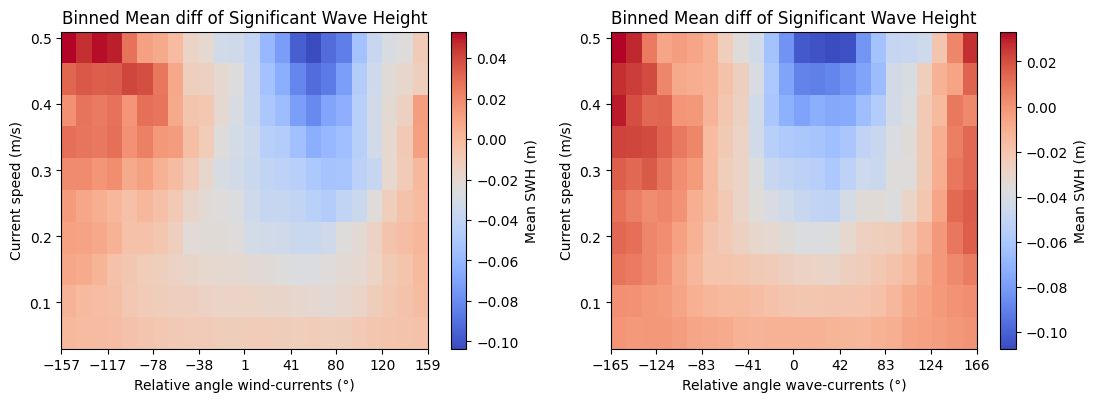

In [95]:
import os

Phenom_period = ["Formation","Intense period","Dissipitation"]
period = 2

bounds, _ = adaptive_percentile_range(diff_swh[0])
vmin, vmax = bounds

#fig, ax = plt.subplots(figsize=(10, 5))

fig = plt.figure(figsize=(13, 14))

ax1 = fig.add_subplot(3, 2, 1)
ax2 = fig.add_subplot(3, 2, 2)
#ax3 = fig.add_subplot(3, 2, 3)
#ax4 = fig.add_subplot(3, 2, 4)
#ax5 = fig.add_subplot(3, 2, 5)

#norm = colors.Normalize(vmin=-0.02, vmax=0.02)

norm = colors.Normalize(vmin=vmin, vmax=vmax)
im = ax1.imshow(
    diff_swh[0], 
    origin='lower',               # so lower left corresponds to smallest bins
    aspect='auto',                # to avoid distortion
    extent=[mask_bins_1[0][0], mask_bins_1[0][-1], mask_bins_2[0][0], mask_bins_2[0][-1]], 
    cmap='coolwarm',                # choose a color map you like (e.g. 'plasma', 'coolwarm', 'turbo')
    #norm=norm
)
plt.colorbar(im, label='Mean SWH (m)')

ax1.set_xticks(mask_bins_1[0][::3])
ax1.set_xlabel('Relative angle wind-currents (°)')
ax1.set_ylabel('Current speed (m/s)')
ax1.set_title('Binned Mean diff of Significant Wave Height')

im = ax2.imshow(
    diff_swh[1], 
    origin='lower',               # so lower left corresponds to smallest bins
    aspect='auto',                # to avoid distortion
    extent=[mask_bins_1[1][0], mask_bins_1[1][-1], mask_bins_2[1][0], mask_bins_2[1][-1]], 
    cmap='coolwarm',                # choose a color map you like (e.g. 'plasma', 'coolwarm', 'turbo')
    #norm=norm
)
plt.colorbar(im, label='Mean SWH (m)')

ax2.set_xticks(mask_bins_1[1][::3])
ax2.set_xlabel('Relative angle wave-currents (°)')
ax2.set_ylabel('Current speed (m/s)')
ax2.set_title('Binned Mean diff of Significant Wave Height')

"""bounds, _ = adaptive_percentile_range(diff_swh[2])
vmin, vmax = bounds
norm_2 = colors.Normalize(vmin=vmin, vmax=vmax)

im = ax3.imshow(
    diff_swh[2], 
    origin='lower',               # so lower left corresponds to smallest bins
    aspect='auto',                # to avoid distortion
    extent=[mask_bins_1[2][0], mask_bins_1[2][-1], mask_bins_2[2][0], mask_bins_2[2][-1]], 
    cmap='coolwarm',                # choose a color map you like (e.g. 'plasma', 'coolwarm', 'turbo')
    norm=norm_2
)
plt.colorbar(im, label='Mean SWH (m)')

ax3.set_xticks(mask_bins_1[2][::3])
ax3.set_xlabel('Relative angle wave-currents (°)')
ax3.set_ylabel('Current speed (m/s)')
ax3.set_title('Binned Mean diff of Significant Wave Height')

im = ax4.imshow(
    diff_swh[3], 
    origin='lower',               # so lower left corresponds to smallest bins
    aspect='auto',                # to avoid distortion
    extent=[mask_bins_1[3][0], mask_bins_1[3][-1], mask_bins_2[3][0], mask_bins_2[3][-1]], 
    cmap="coolwarm",                # choose a color map you like (e.g. 'plasma', 'coolwarm', 'turbo')
    norm=norm
)
plt.colorbar(im, label='Mean SWH (m)')

ax4.set_xticks(mask_bins_1[3][::3])
ax4.set_xlabel('Relative angle wave-currents (°)')
ax4.set_ylabel('Current speed (m/s)')
ax4.set_title('Binned Mean diff of Significant Wave Height')

bounds, _ = adaptive_percentile_range(diff_swh[4])
vmin, vmax = bounds
norm_4 = colors.Normalize(vmin=vmin, vmax=vmax)

im = ax5.imshow(
    diff_swh[4], 
    origin='lower',               # so lower left corresponds to smallest bins
    aspect='auto',                # to avoid distortion
    extent=[mask_bins_1[4][0], mask_bins_1[4][-1], mask_bins_2[4][0], mask_bins_2[4][-1]], 
    cmap='coolwarm',                # choose a color map you like (e.g. 'plasma', 'coolwarm', 'turbo')
    norm=norm_4
)
plt.colorbar(im, label='Mean SWH (m)')

ax5.set_xticks(mask_bins_1[4][::3])
ax5.set_xlabel('Relative angle wave-currents (°)')
ax5.set_ylabel('Current speed (m/s)')
ax5.set_title('Binned Mean diff of Significant Wave Height')"""

"""# Define the full path for the file, including the non-existent directory
output_file = f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Analysis//Ianos//Diff vs currents speed and relative angle between waves and currents//{Phenom_period[period]}.png"

# Extract the directory path from the file path
directory = os.path.dirname(output_file)

# Create the directory if it does not exist, including any intermediate directories
if not os.path.exists(directory):
    os.makedirs(directory, exist_ok=True) # exist_ok=True prevents error if dir already exists

fig.savefig(output_file)
"""

In [98]:
mask_n_bins_1 = [n_speed_bins, n_angle_bins, n_angle_bins]

mask_n_bins_2 = [n_speed_bins, n_speed_bins, n_speed_bins]

diff_wave_dir_0 = np.full((n_speed_bins, mask_n_bins_1[0]), np.nan)
diff_wave_dir_1 = np.full((n_speed_bins, mask_n_bins_1[1]), np.nan) 
diff_wave_dir_2 = np.full((n_speed_bins, mask_n_bins_1[2]), np.nan)
diff_wave_dir = [diff_wave_dir_0, diff_wave_dir_1, diff_wave_dir_2]

mask_cond_1 = [100*normal_vor_masked, rel_angle_wave, angle_bet_input_wave]

mask_bins_1 = [100*refraction_bins, rel_angle_cur_waves_bins, input_angle_bins]

mask_cond_2 = [cur_speed, 100*normal_vor_masked, cur_speed]

mask_bins_2 = [cur_speed_bins, 100*refraction_bins, cur_speed_bins]

for k in range(0,3):
    for i in range(mask_n_bins_1[k]):
        for j in range(mask_n_bins_2[k]):
            mask_bin = (
                (np.asarray(mask_cond_1[k]) >= mask_bins_1[k][i]) & 
                (np.asarray(mask_cond_1[k]) < mask_bins_1[k][i + 1]) 
                &
                (np.asarray(mask_cond_2[k]) >= mask_bins_2[k][j]) & 
                (np.asarray(mask_cond_2[k]) < mask_bins_2[k][j + 1])
            )
            if np.any(mask_bin):
                diff_wave_dir[k][j,i] = np.nanmean(diff_wave_dir2d[mask_bin]) 

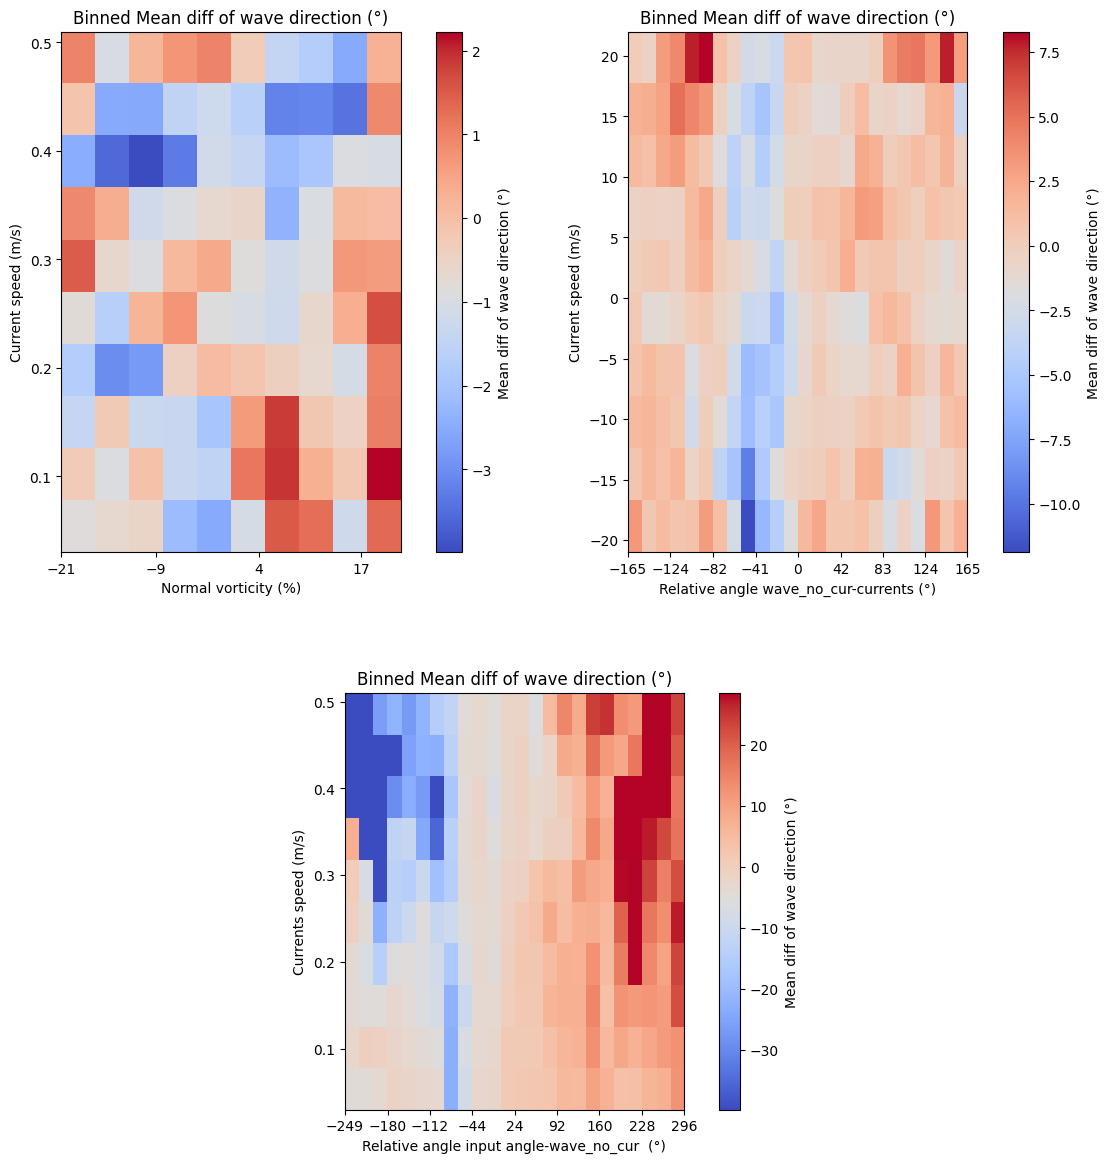

In [99]:
import os

Phenom_period = ["Formation","Intense period","Dissipitation"]
period = 2

mosaic = """
AABB
.II."""

fig, ax_dict = plt.subplot_mosaic(
    mosaic,
    figsize=(13, 14),
    # subplot_kw={'projection': ccrs.PlateCarree()},
    gridspec_kw={'height_ratios': [1, 0.8]},
    #sharey=True
)

# Assign axis variables
ax1 = ax_dict["A"]
ax2 = ax_dict["B"]
ax3 = ax_dict["I"]

plt.subplots_adjust(hspace=0.3, wspace=0.8)  # increase vertical spacing

im = ax1.imshow(
    diff_wave_dir[0], 
    origin='lower',               # so lower left corresponds to smallest bins
    aspect='auto',                # to avoid distortion
    extent=[mask_bins_1[0][0], mask_bins_1[0][-1], mask_bins_2[0][0], mask_bins_2[0][-1]], 
    cmap='coolwarm',                # choose a color map you like (e.g. 'plasma', 'coolwarm', 'turbo')
    #norm=norm
)
cbar = fig.colorbar(im,pad=0.08,ax =ax1,label="Mean diff of wave direction (°)")


ax1.set_xticks(mask_bins_1[0][::3])
ax1.set_xlabel('Normal vorticity (%)')
ax1.set_ylabel('Current speed (m/s)')
ax1.set_title('Binned Mean diff of wave direction (°)')

im = ax2.imshow(
    diff_wave_dir[1], 
    origin='lower',               # so lower left corresponds to smallest bins
    aspect='auto',                # to avoid distortion
    extent=[mask_bins_1[1][0], mask_bins_1[1][-1], mask_bins_2[1][0], mask_bins_2[1][-1]], 
    cmap='coolwarm',                # choose a color map you like (e.g. 'plasma', 'coolwarm', 'turbo')
    #norm=norm
)
cbar = fig.colorbar(im,pad=0.08,ax =ax2,label="Mean diff of wave direction (°)")

ax2.set_xticks(mask_bins_1[1][::3])
ax2.set_xlabel('Relative angle wave_no_cur-currents (°)')
ax2.set_ylabel('Current speed (m/s)')
ax2.set_title('Binned Mean diff of wave direction (°)')

bounds, _ = adaptive_percentile_range(diff_wave_dir[2])
vmin, vmax = bounds
norm_3 = colors.Normalize(vmin=vmin, vmax=vmax)

im = ax3.imshow(
    diff_wave_dir[2], 
    origin='lower',               # so lower left corresponds to smallest bins
    aspect='auto',                # to avoid distortion
    extent=[mask_bins_1[2][0], mask_bins_1[2][-1], mask_bins_2[2][0], mask_bins_2[2][-1]], 
    cmap='coolwarm',                # choose a color map you like (e.g. 'plasma', 'coolwarm', 'turbo')
    norm=norm_3
)
cbar = fig.colorbar(im,pad=0.08,ax =ax3,label="Mean diff of wave direction (°)")

ax3.set_xticks(mask_bins_1[2][::3])
ax3.set_xlabel('Relative angle input angle-wave_no_cur  (°)')
ax3.set_ylabel('Currents speed (m/s)')
ax3.set_title('Binned Mean diff of wave direction (°)')

# Define the full path for the file, including the non-existent directory
output_file = f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Analysis//Ianos//Diff vs currents speed and relative angle between waves and currents//Wave dir//{Phenom_period[period]}.png"

# Extract the directory path from the file path
directory = os.path.dirname(output_file)

# Create the directory if it does not exist, including any intermediate directories
if not os.path.exists(directory):
    os.makedirs(directory, exist_ok=True) # exist_ok=True prevents error if dir already exists

fig.savefig(output_file)
